# Preprocessing & Pelabelan Awal — IndoRoBERTa

**Notebook:** `02_preprocessing_and_labeling.ipynb`  
**Peneliti:** Khoeru Roziqin  
**Tanggal:** 25-4-26  

---

## Deskripsi

Notebook ini menjalankan dua proses utama dalam alur penelitian analisis sentimen Program Makan Bergizi Gratis (MBG):

### 1. Preprocessing Teks
Pipeline preprocessing dirancang khusus untuk model berbasis Transformer (IndoRoBERTa & IndoBERT+CNN). Pipeline menghasilkan satu varian teks:
- **`text_bert`**: Teks yang dioptimalkan untuk model Transformer — berhenti pada tahap normalisasi (Step 1–4) **tanpa** stemming dan stopword removal, karena IndoBERT/IndoRoBERTa dilatih pada teks natural bahasa Indonesia.

### 2. Pelabelan Awal Otomatis
Model **`w11wo/indonesian-roberta-base-sentiment-classifier`** (IndoRoBERTa) digunakan sebagai *pseudo-annotator* (anotator ke-2) untuk menghasilkan label sentimen otomatis. Label ini digunakan untuk menghitung **Cohen's Kappa (κ)** sebagai metrik Inter-Annotator Agreement (IAA) terhadap label manual peneliti.

---

## Pipeline Preprocessing

| Step | Nama | Keterangan |
|---|---|---|
| 1 | Case Folding | Lowercase + decode HTML entities |
| 2 | Cleaning | URL, mention, emoji, hashtag, currency, normalisasi karakter |
| 3 | Tokenization | Whitespace split (parsing helper) |
| 4 | Normalization | Kamus slang, negasi, dedup frasa → **OUTPUT `text_bert`** |

> ❌ Stemming dan stopword removal **tidak diterapkan** pada `text_bert`. IndoBERT menggunakan subword tokenizer (WordPiece) yang membutuhkan teks natural — stemming menghasilkan token OOV dan merusak representasi kontekstual.

---

## Justifikasi Pemilihan Model IndoRoBERTa

| Kriteria | Keterangan |
|---|---|
| **Arsitektur** | RoBERTa — varian BERT yang dioptimalkan dengan training lebih robust |
| **Bahasa** | Dilatih pada korpus bahasa Indonesia |
| **Task** | Fine-tuned untuk sentiment classification 3 kelas (Positif/Negatif/Netral) |
| **Peran** | Pseudo-annotator untuk perhitungan IAA (Cohen's Kappa) |

**Referensi:**  
- Liu, Y., et al. (2019). RoBERTa: A Robustly Optimized BERT Pretraining Approach. *arXiv:1907.11692*.  
- Cohen, J. (1960). A coefficient of agreement for nominal scales. *Educational and Psychological Measurement*, 20(1), 37–46.  
- Landis, J. R., & Koch, G. G. (1977). The measurement of observer agreement for categorical data. *Biometrics*, 33(1), 159–174.

## 0. Setup & Mount Google Drive

Mount Google Drive untuk akses data dan kamus preprocessing. `PySastrawi` diinstal untuk kompatibilitas library — **tidak digunakan** dalam pipeline preprocessing BERT (hanya untuk memastikan environment lengkap).

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install transformers torch PySastrawi -q

import os, re, warnings, requests
import numpy as np
import pandas as pd
import torch
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import cohen_kappa_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.auto import tqdm
import nltk
nltk.download('punkt', quiet=True)
warnings.filterwarnings('ignore')
tqdm.pandas()

DEVICE = 0 if torch.cuda.is_available() else -1
print(f'GPU tersedia : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU device   : {torch.cuda.get_device_name(0)}')
    print(f'VRAM         : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print(f'PyTorch      : {torch.__version__}')

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.6/210.6 kB 7.4 MB/s eta 0:00:00
GPU tersedia : True
GPU device   : Tesla T4
VRAM         : 15.6 GB
PyTorch      : 2.10.0+cu128


## 1. Konfigurasi Path & Parameter

Seluruh path dan parameter penelitian didefinisikan terpusat di sel ini.

In [2]:
# ── PATH ─────────────────────────────────────────────────────────────────────
BASE_DIR    = '/content/drive/My Drive/skripsi/dataset/mbg'
PATH_KAMUS  = f'{BASE_DIR}/preprocessing'
INPUT_PATH  = f'{BASE_DIR}/processed/mbg_sampled_labeled.csv'
OUTPUT_PATH = f'{BASE_DIR}/processed/mbg_labeled.csv'
OUTPUT_DIR  = f'{BASE_DIR}/processed'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── PARAMETER ────────────────────────────────────────────────────────────────
RANDOM_SEED   = 42
BATCH_SIZE    = 32
MAX_LENGTH    = 128
MIN_WORD_COUNT = 3
ROBERTA_MODEL = 'w11wo/indonesian-roberta-base-sentiment-classifier'

LABEL_MAP = {
    'positive':'positive', 'neutral':'neutral', 'negative':'negative',
    'POSITIVE':'positive', 'NEUTRAL':'neutral', 'NEGATIVE':'negative',
    'LABEL_0' :'negative', 'LABEL_1' :'neutral', 'LABEL_2' :'positive',
}

print('Konfigurasi berhasil dimuat.')
print(f'Input          : {INPUT_PATH}')
print(f'Output         : {OUTPUT_PATH}')
print(f'Model          : {ROBERTA_MODEL}')
print(f'Batch size     : {BATCH_SIZE}')
print(f'Max length     : {MAX_LENGTH}')

Konfigurasi berhasil dimuat.
Input          : /content/drive/My Drive/skripsi/dataset/mbg/processed/mbg_sampled_labeled.csv
Output         : /content/drive/My Drive/skripsi/dataset/mbg/processed/mbg_labeled.csv
Model          : w11wo/indonesian-roberta-base-sentiment-classifier
Batch size     : 32
Max length     : 128


## 2. Load Kamus & Resource Bahasa

Memuat seluruh kamus custom yang digunakan dalam pipeline preprocessing:

| File | Deskripsi |
|---|---|
| `demoji_code_mbg.csv` | Pemetaan emoji → frasa bahasa Indonesia (frequency-based) |
| `akun_x_mbg.csv` | Pemetaan mention akun penting → nama asli |
| `kamus_alay_mbg.csv` | Kamus slang/alay custom domain MBG |
| `whitelist_hashtag_mbg.csv` | Hashtag relevan MBG yang dipertahankan dan dikonversi |
| `additional_stopwords_mbg.csv` | Dimuat untuk kelengkapan — tidak digunakan di pipeline BERT |

Kamus slang digabungkan dengan kamus Nasal (colloquial Indonesian lexicon). Kamus custom **override** Nasal untuk kata-kata spesifik domain MBG.

In [3]:
def load_dict_csv(filename, required_cols=None):
    path = os.path.join(PATH_KAMUS, filename)
    if not os.path.exists(path):
        print(f'  ⚠️  File tidak ditemukan: {filename}')
        return pd.DataFrame(columns=required_cols or ['original_term','replacement'])
    return pd.read_csv(path, on_bad_lines='skip')

print('Memuat kamus custom...')
df_demoji = load_dict_csv('demoji_code_mbg.csv')
df_akun   = load_dict_csv('akun_x_mbg.csv')
df_alay   = load_dict_csv('kamus_alay_mbg.csv')
df_wl     = load_dict_csv('whitelist_hashtag_mbg.csv')

# Load kamus Nasal (colloquial Indonesian lexicon)
print('Memuat kamus Nasal...')
!wget -q -N https://raw.githubusercontent.com/nasalsabila/kamus-alay/master/colloquial-indonesian-lexicon.csv
df_nasal = pd.read_csv('colloquial-indonesian-lexicon.csv')

# ── Konversi ke dict ──────────────────────────────────────────────────────────
whitelist_hashtags = set(
    df_wl['hashtag'].astype(str).str.lower().str.strip()
) if not df_wl.empty else set()

dict_demoji = {
    str(k).strip(): str(v).strip()
    for k, v in zip(df_demoji.get('original_term', []), df_demoji.get('replacement', []))
    if pd.notna(k) and pd.notna(v) and str(k).strip() != ''
}

dict_akun = {
    str(k).strip(): str(v).strip()
    for k, v in zip(df_akun.get('original_term', []), df_akun.get('replacement', []))
    if pd.notna(k) and pd.notna(v)
}

# Merge kamus alay: Nasal sebagai base, custom sebagai override
full_dict_alay = {
    str(k).lower(): str(v).lower()
    for k, v in zip(df_nasal['slang'], df_nasal['formal'])
    if pd.notna(k) and pd.notna(v)
}
dict_custom = {
    str(k).lower(): str(v).lower()
    for k, v in zip(df_alay.get('original_term', []), df_alay.get('replacement', []))
    if pd.notna(k) and pd.notna(v)
}
full_dict_alay.update(dict_custom)  # custom override nasal

# Perbarui daftar singkatan yang TIDAK BOLEH diubah oleh kamus alay manapun
protected_words = ['sma', 'smp', 'sd', 'tk', 'pt']

for word in protected_words:
    if word in full_dict_alay:
        del full_dict_alay[word] # Hapus dari aturan normalisasi
        print(f"   🛡️ Proteksi Aktif: '{word}' tidak akan diubah.")

dict_phrases   = {k: v for k, v in full_dict_alay.items() if ' ' in k}
dict_words     = {k: v for k, v in full_dict_alay.items() if ' ' not in k}
sorted_phrases = sorted(dict_phrases.keys(), key=len, reverse=True)

print(f'\n✅ Resource bahasa berhasil dimuat.')
print(f'   Emoji mapping     : {len(dict_demoji):,} entri')
print(f'   Akun mapping      : {len(dict_akun):,} entri')
print(f'   Whitelist hashtag : {len(whitelist_hashtags):,} tag')
print(f'   Kamus alay total  : {len(full_dict_alay):,} ({len(dict_phrases):,} frasa, {len(dict_words):,} kata)')

Memuat kamus custom...
Memuat kamus Nasal...
   🛡️ Proteksi Aktif: 'sma' tidak akan diubah.
   🛡️ Proteksi Aktif: 'smp' tidak akan diubah.
   🛡️ Proteksi Aktif: 'sd' tidak akan diubah.
   🛡️ Proteksi Aktif: 'tk' tidak akan diubah.
   🛡️ Proteksi Aktif: 'pt' tidak akan diubah.

✅ Resource bahasa berhasil dimuat.
   Emoji mapping     : 284 entri
   Akun mapping      : 88 entri
   Whitelist hashtag : 330 tag
   Kamus alay total  : 11,894 (206 frasa, 11,688 kata)


## 3. Pipeline Preprocessing (Step 1–4)

Pipeline terdiri dari 4 step modular yang menghasilkan `text_bert` sebagai output tunggal.

### Mengapa tidak ada stemming & stopword removal?
IndoBERT dan IndoRoBERTa dilatih menggunakan teks bahasa Indonesia yang **natural dan utuh**. Penerapan stemming akan mengubah surface form kata sehingga berpotensi menghasilkan token yang tidak dikenal (OOV) oleh subword tokenizer. Stopword removal menghilangkan konteks sintaksis yang dibutuhkan attention mechanism — misalnya, menghapus kata negasi seperti *"tidak"* dapat **membalik sentimen** secara keseluruhan.

```
Step 1 → Case Folding & HTML Unescape
Step 2 → Cleaning (URL, mention, emoji, hashtag, currency, karakter)
Step 3 → Tokenization (whitespace split — parsing helper)
Step 4 → Normalization (slang, negasi, dedup) → OUTPUT: text_bert
```

In [4]:
# ══════════════════════════════════════════════════════════════════
#  STEP 1 — CASE FOLDING & HTML UNESCAPE
# ══════════════════════════════════════════════════════════════════
def step1_casefolding(text):
    """Lowercase + decode HTML entities yang umum di Twitter."""
    if pd.isna(text) or str(text).strip() == '': return ''
    temp = str(text)
    temp = temp.replace('&amp;',  ' dan ')
    temp = temp.replace('&lt;',   ' kurang dari ')
    temp = temp.replace('&gt;',   ' lebih dari ')
    temp = temp.replace('&quot;', '"')
    temp = temp.replace('&#39;',  "'")
    return temp.lower()


# ══════════════════════════════════════════════════════════════════
#  STEP 2 — CLEANING
# ══════════════════════════════════════════════════════════════════
def step2_cleaning(text):
    """Pembersihan menyeluruh dengan mempertahankan sinyal sentimen."""
    if not text: return ''
    temp = text

    # 2.1 Emotikon teks ASCII
    temp = re.sub(r'[:;=x][\-~]?[)d\]]+', ' senang ', temp)
    temp = re.sub(r'[:;=x][\-~]?[(\[]+',  ' sedih ',  temp)

    # 2.2 Hapus URL
    temp = re.sub(r'http\S+|www\S+|https\S+', ' ', temp, flags=re.MULTILINE)

    # 2.3 Singkatan domain dalam kurung (tidak informatif)
    for pat in [r'\(\s*mbg\s*\)', r'\(\s*bgn\s*\)',
                r'\(\s*apbn\s*\)', r'\(\s*as\s*\)']:
        temp = re.sub(pat, ' ', temp)

    # 2.4 Normalisasi whitespace & newline
    temp = temp.replace('\n', ' . ')
    temp = re.sub(r'[\t\xa0]', ' ', temp)
    temp = re.sub(r'([?!,.])(?=[a-z#])', r'\1 ', temp)

    # 2.5 Normalisasi suffix slang possesif (otak'nya → otaknya)
    temp = re.sub(r"(?<=[a-z])['`]+[ya]\b", 'nya', temp)

    # 2.6 Penyelamat huruf tunggal (s-nya → huruf s nya)
    temp = re.sub(r'\b([a-z])(?:-|\'|\s)*nya\b', r'huruf \1 nya', temp)

    # 2.7 Pemangkas repetisi huruf berlebih (enaaaaak → enak)
    temp = re.sub(r'([a-z])\1{2,}', r'\1', temp)

    # 2.8 Hashtag: whitelist → pertahankan teks, non-whitelist → hapus
    for tag in re.findall(r'#\w+', temp):
        clean_tag = tag.lower().lstrip('#')
        if clean_tag in whitelist_hashtags or tag.lower() in whitelist_hashtags:
            temp = temp.replace(tag, ' ' + tag[1:] + ' ')
        else:
            temp = temp.replace(tag, ' ')

    # 2.9 Mention: penting → nama asli (kamus), sisanya hapus
    for k, v in dict_akun.items():
        temp = re.sub(re.escape(k), ' ' + v + ' ', temp, flags=re.IGNORECASE)
    temp = re.sub(r'@\w+', ' ', temp)

    # 2.10 Emoji → frasa (kamus custom frequency-based)
    for k, v in dict_demoji.items():
        temp = temp.replace(k, ' ' + v + ' ')

    # 2.11 Normalisasi kata ulang angka (anak2 → anak anak)
    temp = re.sub(
        r'\b([a-z]{2,})2(nya|ny|ku|mu|an|in|kan|san|kah|lah|pun|)\b',
        r'\1 \1\2', temp
    )

    # 2.12 Currency shield — lindungi konteks nilai uang
    temp = re.sub(r'\b(?:rp|rupiah)\s*[.,]?\s*(\d)', r'rp \1', temp)
    def _ubah_mata_uang(m):
        angka  = m.group(1).replace(' ', ',')
        suffix = m.group(2)
        peta   = {
            'k':'ribu',  'rb':'ribu',    'ribu':'ribu',
            'jt':'juta', 'juta':'juta',
            'm':'miliar','miliar':'miliar','milyar':'miliar',
            't':'triliun','triliun':'triliun','triliyun':'triliun',
            'perak':'rupiah'
        }
        return f"{angka} {peta[suffix]}"
    temp = re.sub(
        r'\b(\d+(?:[.,\s]\d+)?)\s*'
        r'(k|rb|ribu|jt|juta|m|miliar|milyar|t|triliun|triliyun|perak)\b',
        _ubah_mata_uang, temp
    )
    # Hilangkan titik ribuan pada angka (rp 15.000 → rp 15000)
    temp = re.sub(
        r'\b(\d{1,3}(?:\.\d{3})+)\b',
        lambda m: m.group(1).replace('.', ''), temp
    )

    # 2.13 Hapus format tanggal numerik (DD/MM/YYYY)
    temp = re.sub(r'\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b', ' ', temp)
    _bulan = (r'(januari|februari|maret|april|mei|juni|juli|'
              r'agustus|september|oktober|november|desember)')
    temp = re.sub(rf'\b\d{{1,2}}\s+{_bulan}\s+\d{{2,4}}\b', ' tanggal ', temp)
    temp = re.sub(r'\b\d{{1,2}}[:.\-]\d{{2}}(?:[:.\-]\d{{2}})?\b', ' ', temp)

    # 2.14 Pecahan & persen
    temp = re.sub(r'(?<!\w)1/2(?!\w)', ' setengah ',   temp)
    temp = re.sub(r'(?<!\w)1/3(?!\w)', ' sepertiga ',  temp)
    temp = re.sub(r'(?<!\w)1/4(?!\w)', ' seperempat ', temp)
    temp = re.sub(r'(?<!\w)3/4(?!\w)', ' tiga perempat ', temp)
    temp = re.sub(r'(?<!\w)(\d+)/(\d+)(?!\w)', r'\1 per \2', temp)
    temp = temp.replace('%', ' persen ')

    # 2.15 Normalisasi tanda baca berlebih
    temp = re.sub(r'\.{3,}', ' ... ', temp)
    temp = re.sub(r'(?<!\.)\.\.(?!\.)', ' . ', temp)
    temp = re.sub(r'[^a-z0-9\s\?\!\,\.]', ' ', temp)

    return re.sub(r'\s+', ' ', temp).strip()


# ══════════════════════════════════════════════════════════════════
#  STEP 3 — TOKENIZATION (parsing helper)
# ══════════════════════════════════════════════════════════════════
def step3_tokenization(text):
    """Whitespace split sebagai parsing helper untuk normalisasi.
    Bukan output final — hanya memfasilitasi matching kamus."""
    if not text: return ''
    return ' '.join(text.split())


# ══════════════════════════════════════════════════════════════════
#  STEP 4 — NORMALIZATION → OUTPUT: text_bert
# ══════════════════════════════════════════════════════════════════
def step4_normalization(text):
    """Normalisasi slang, negasi, dan dedup frasa.
    Menghasilkan text_bert — output akhir pipeline BERT."""
    if not text: return ''
    temp = ' ' + text + ' '

    # 4.1 Normalisasi frasa (longest match first)
    for phrase in sorted_phrases:
        if phrase in temp:
            temp = re.sub(
                r'\b' + re.escape(phrase) + r'\b',
                ' ' + dict_phrases[phrase] + ' ', temp
            )

    # 4.2 Normalisasi kata tunggal
    tokens = temp.split()
    temp   = ' '.join([dict_words.get(w, w) for w in tokens])

    # 4.3 Normalisasi negasi (word boundary ketat)
    temp = re.sub(r'\bnggak\b', 'tidak', temp)
    temp = re.sub(r'\bngga\b',  'tidak', temp)
    temp = re.sub(r'\bgak\b',   'tidak', temp)
    temp = re.sub(r'\bga\b',    'tidak', temp)

    # 4.4 Dedup frasa hasil ekspansi whitelist/kamus
    for phrase in ['makan bergizi gratis', 'badan gizi nasional',
                   'anggaran pendapatan dan belanja negara']:
        temp = re.sub(
            rf'\b({re.escape(phrase)})(\s+\1)+\b', r'\1', temp
        )

    return re.sub(r'\s+', ' ', temp).strip()


# ══════════════════════════════════════════════════════════════════
#  MASTER PIPELINE
# ══════════════════════════════════════════════════════════════════
def preprocess(text):
    """Pipeline preprocessing lengkap (Step 1–4).
    Returns: str text_bert — siap untuk IndoRoBERTa & IndoBERT+CNN.
    """
    s1 = step1_casefolding(text)
    s2 = step2_cleaning(s1)
    s3 = step3_tokenization(s2)
    s4 = step4_normalization(s3)
    return s4


print('✅ Pipeline preprocessing (Step 1–4) berhasil didefinisikan.')
print('   Output: text_bert (untuk IndoRoBERTa & IndoBERT+CNN)')

✅ Pipeline preprocessing (Step 1–4) berhasil didefinisikan.
   Output: text_bert (untuk IndoRoBERTa & IndoBERT+CNN)


## 4. Pengujian Pipeline Preprocessing

Validasi pipeline dengan 5 kasus representatif sebelum diterapkan ke seluruh dataset. Pengujian ini memastikan setiap edge case tertangani dengan benar.

In [5]:
test_cases = [
    # Kasus 1: HTML entity, persen, repetisi huruf, emoji ASCII
    "Anggaran MBG &amp; bansos cair barengan? &lt; 50% yg sampai desa. Keren bangeeeetttt =D",
    # Kasus 2: Angka uang, URL, hashtag MBG, format tanggal
    "program makan bergizi gratis (mbg) ini anggarannya rp.15.000 lho di tanggal 17/04/2025\nkeren banget...indonesia.#mbg",
    # Kasus 3: Pecahan, negasi, sarkasme
    "hampir 50% dana dipotong? gila aja! 1/2 nya dikorupsi kali ya?!",
    # Kasus 4: Negasi ga/gak
    "makanannya ga enak sama sekali, gak layak buat anak sekolah",
    # Kasus 5: Mention penting, kata ulang angka
    "@prabowo bilang program ini bagus2 tapi kenyataannya gimana? kita sma sama berusaha, tetap banyak anak SMA yang keracunan.",
]

print('=== PENGUJIAN PIPELINE PREPROCESSING ===')
for i, tc in enumerate(test_cases, 1):
    result = preprocess(tc)
    print(f'\n🧪 Kasus {i}:')
    print(f'  ORIGINAL  : {tc[:100]}...' if len(tc) > 100 else f'  ORIGINAL  : {tc}')
    print(f'  TEXT_BERT : {result}')
    print(f'  Jumlah kata: {len(result.split())}')
    print('─' * 65)

=== PENGUJIAN PIPELINE PREPROCESSING ===

🧪 Kasus 1:
  ORIGINAL  : Anggaran MBG &amp; bansos cair barengan? &lt; 50% yg sampai desa. Keren bangeeeetttt =D
  TEXT_BERT : anggaran makan bergizi gratis dan bantuan sosial cair barengan? kurang dari 50 persen yang sampai desa. keren sangat senang
  Jumlah kata: 19
─────────────────────────────────────────────────────────────────

🧪 Kasus 2:
  ORIGINAL  : program makan bergizi gratis (mbg) ini anggarannya rp.15.000 lho di tanggal 17/04/2025
keren banget....
  TEXT_BERT : program makan bergizi gratis ini anggaran rp 15000 loh di tanggal . keren sangat ... indonesia. makan bergizi gratis
  Jumlah kata: 19
─────────────────────────────────────────────────────────────────

🧪 Kasus 3:
  ORIGINAL  : hampir 50% dana dipotong? gila aja! 1/2 nya dikorupsi kali ya?!
  TEXT_BERT : hampir 50 persen dana dipotong? gila aja! setengah nya dikorupsi kali ya?!
  Jumlah kata: 12
─────────────────────────────────────────────────────────────────

🧪 Kasus 4:
  O

## 5. Terapkan Preprocessing ke Seluruh Dataset

Menerapkan pipeline preprocessing ke semua tweet dalam `mbg_sampled_labeled.csv`. Setelah preprocessing, dilakukan **post-filtering** untuk menghapus tweet yang menjadi terlalu pendek (≤ 3 kata) atau kosong.

In [6]:
print('Memuat data sampled...')
df = pd.read_csv(INPUT_PATH, low_memory=False)
n_raw = len(df)
print(f'Data loaded: {n_raw:,} baris')
print(f'Kolom: {list(df.columns)}')

# Pastikan kolom teks tersedia
assert 'full_text' in df.columns, "Kolom 'full_text' tidak ditemukan!"

# Terapkan pipeline preprocessing
print('\nMenerapkan preprocessing (Step 1–4)...')
df['text_bert'] = df['full_text'].progress_apply(preprocess)

# ── Post-filtering ────────────────────────────────────────────────────────────
n_before = len(df)
df['bert_word_count'] = df['text_bert'].str.split().str.len().fillna(0).astype(int)

# Hapus tweet kosong atau terlalu pendek setelah preprocessing
df = df[df['text_bert'].str.strip() != ''].copy()
df = df[df['bert_word_count'] > MIN_WORD_COUNT].copy()
df = df.reset_index(drop=True)
n_after = len(df)

print(f'\nSebelum post-filtering : {n_before:,}')
print(f'Setelah post-filtering : {n_after:,} (-{n_before - n_after:,} tweet terlalu pendek/kosong)')

# Statistik panjang tweet setelah preprocessing
print(f'\nStatistik panjang text_bert:')
stats = df['bert_word_count'].describe()
print(f'  Mean   : {stats["mean"]:.2f} kata')
print(f'  Median : {stats["50%"]:.0f} kata')
print(f'  Min    : {stats["min"]:.0f} kata')
print(f'  Max    : {stats["max"]:.0f} kata')

print(f'\nContoh hasil preprocessing (3 baris):')
df[['full_text', 'text_bert', 'bert_word_count']].head(3)

Memuat data sampled...
Data loaded: 6,500 baris
Kolom: ['id_str', 'created_at', 'period', 'full_text', 'word_count', 'username', 'user_id_str', 'favorite_count', 'retweet_count', 'reply_count', 'quote_count', 'lang', 'location', 'source_keyword', 'label', 'label_roberta', 'annotator_notes']

Menerapkan preprocessing (Step 1–4)...


  0%|          | 0/6500 [00:00<?, ?it/s]


Sebelum post-filtering : 6,500
Setelah post-filtering : 6,499 (-1 tweet terlalu pendek/kosong)

Statistik panjang text_bert:
  Mean   : 25.79 kata
  Median : 24 kata
  Min    : 4 kata
  Max    : 79 kata

Contoh hasil preprocessing (3 baris):


,full_text,text_bert,bert_word_count
0,"Faktor Kecemburuan Sosial, MUI Desak Pemerinta...","faktor kecemburuan sosial, majelis ulama indon...",13
1,"Kepala Seksi Intelijen, Akhmad Putra Dwi, S.H....","kepala seksi intelijen, ahmad putra dwi, s. h....",38
2,dengan makan bergizi gratis generasi sehat sia...,dengan makan bergizi gratis generasi sehat sia...,16


## 6. Pelabelan Awal — IndoRoBERTa

Model `w11wo/indonesian-roberta-base-sentiment-classifier` digunakan untuk menghasilkan label sentimen otomatis beserta confidence score. Model ini berfungsi sebagai **anotator ke-2 (pseudo-annotator)** untuk keperluan perhitungan IAA.

**Input model**: `text_bert` — teks yang sudah melalui preprocessing Step 1–4, konsisten dengan preprocessing yang akan digunakan pada IndoBERT+CNN.

**Output per tweet**:
- `label_roberta`: Label prediksi (positive / negative / neutral)
- `confidence_roberta`: Confidence score (0.0–1.0)

> **Catatan**: Label IndoRoBERTa **bukan ground truth**. Label ini hanya digunakan untuk menghitung Cohen's Kappa. Ground truth penelitian adalah kolom `label` yang diisi secara manual oleh peneliti.

In [7]:
print(f'Memuat model IndoRoBERTa...')
print(f'Model: {ROBERTA_MODEL}')

tokenizer_rob = AutoTokenizer.from_pretrained(ROBERTA_MODEL)
model_rob     = AutoModelForSequenceClassification.from_pretrained(ROBERTA_MODEL)

sentiment_pipe = pipeline(
    task       = 'sentiment-analysis',
    model      = model_rob,
    tokenizer  = tokenizer_rob,
    device     = DEVICE,
    max_length = MAX_LENGTH,
    truncation = True,
    padding    = True,
)

id2label = model_rob.config.id2label
print(f'\n✅ Model berhasil dimuat.')
print(f'   Label model : {id2label}')
print(f'   Device      : {"GPU" if DEVICE == 0 else "CPU"}')

Memuat model IndoRoBERTa...
Model: w11wo/indonesian-roberta-base-sentiment-classifier


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



✅ Model berhasil dimuat.
   Label model : {0: 'positive', 1: 'neutral', 2: 'negative'}
   Device      : GPU


In [8]:
import time

def run_inference_batched(texts, batch_size=BATCH_SIZE):
    """Inference IndoRoBERTa dalam batch dengan fallback per-item."""
    all_results = []
    total_batches = (len(texts) + batch_size - 1) // batch_size
    t_start = time.time()

    for i in tqdm(range(0, len(texts), batch_size),
                  total=total_batches,
                  desc='Inference IndoRoBERTa',
                  bar_format='{l_bar}{bar:25}{r_bar}'):
        batch = texts[i:i + batch_size].tolist()
        try:
            preds = sentiment_pipe(batch)
            all_results.extend(preds)
        except Exception as e:
            # Fallback: proses satu per satu jika batch gagal
            for text in batch:
                try:
                    all_results.append(sentiment_pipe([text])[0])
                except Exception:
                    all_results.append({'label': 'neutral', 'score': 0.0})

    elapsed = time.time() - t_start
    print(f'Inference selesai — {elapsed/60:.1f} menit ({len(texts):,} tweet)')
    return all_results


print(f'Menjalankan inference pada {len(df):,} tweet (batch size: {BATCH_SIZE})...')
predictions = run_inference_batched(df['text_bert'])

# Ekstrak label dan confidence score
df['label_roberta_raw'] = [p['label'] for p in predictions]
df['confidence_roberta'] = [round(p['score'], 4) for p in predictions]
df['label_roberta'] = df['label_roberta_raw'].map(LABEL_MAP).fillna('neutral')

print(f'\nDistribusi label IndoRoBERTa:')
for lbl, cnt in df['label_roberta'].value_counts().items():
    print(f'  {lbl:12s}: {cnt:,} ({cnt/len(df)*100:.1f}%)')
print(f'\nStatistik confidence score:')
print(df['confidence_roberta'].describe().round(4))

Menjalankan inference pada 6,499 tweet (batch size: 32)...


Inference IndoRoBERTa:   0%|                         | 0/204 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Inference selesai — 1.5 menit (6,499 tweet)

Distribusi label IndoRoBERTa:
  positive    : 2,615 (40.2%)
  neutral     : 2,343 (36.1%)
  negative    : 1,541 (23.7%)

Statistik confidence score:
count    6499.0000
mean        0.8849
std         0.1492
min         0.3406
25%         0.8238
50%         0.9614
75%         0.9914
max         0.9995
Name: confidence_roberta, dtype: float64


## 7. Analisis Distribusi Confidence Score

Visualisasi distribusi confidence score untuk memahami tingkat kepastian model. Tweet dengan confidence rendah (< 0.60) merupakan kasus ambigu yang memerlukan perhatian khusus saat anotasi manual.

> **Panduan anotasi manual**: Prioritaskan review tweet dengan `confidence_roberta < 0.60` karena paling rawan salah label otomatis.

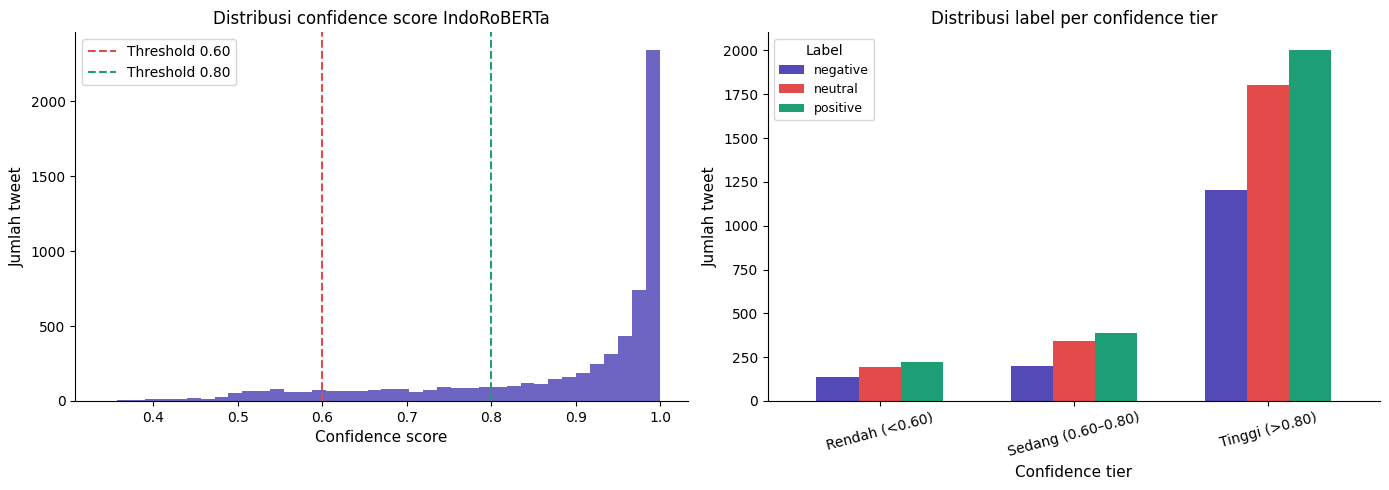

Confidence rendah (<0.60) : 554 (8.5%) — prioritas review manual
Confidence sedang (0.60–0.80): 933 (14.4%)
Confidence tinggi (≥0.80) : 5,012 (77.1%)

✔ Grafik disimpan ke: /content/drive/My Drive/skripsi/dataset/mbg/processed/confidence_distribution.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribusi confidence score keseluruhan
axes[0].hist(df['confidence_roberta'], bins=40,
             color='#534AB7', edgecolor='none', alpha=0.85)
axes[0].axvline(x=0.6, color='#E24B4A', linestyle='--',
                linewidth=1.5, label='Threshold 0.60')
axes[0].axvline(x=0.8, color='#1D9E75', linestyle='--',
                linewidth=1.5, label='Threshold 0.80')
axes[0].set_xlabel('Confidence score', fontsize=11)
axes[0].set_ylabel('Jumlah tweet', fontsize=11)
axes[0].set_title('Distribusi confidence score IndoRoBERTa', fontsize=12)
axes[0].legend(fontsize=10)
sns.despine(ax=axes[0])

# Plot 2: Distribusi label per confidence tier
df['conf_tier'] = pd.cut(
    df['confidence_roberta'],
    bins=[0, 0.6, 0.8, 1.0],
    labels=['Rendah (<0.60)', 'Sedang (0.60–0.80)', 'Tinggi (>0.80)']
)
tier_dist = df.groupby(['conf_tier', 'label_roberta']).size().unstack(fill_value=0)
tier_dist.plot(kind='bar', ax=axes[1],
               color=['#534AB7', '#E24B4A', '#1D9E75'],
               edgecolor='none', width=0.65)
axes[1].set_xlabel('Confidence tier', fontsize=11)
axes[1].set_ylabel('Jumlah tweet', fontsize=11)
axes[1].set_title('Distribusi label per confidence tier', fontsize=12)
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Label', fontsize=9)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confidence_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

n_low  = (df['confidence_roberta'] < 0.6).sum()
n_mid  = ((df['confidence_roberta'] >= 0.6) & (df['confidence_roberta'] < 0.8)).sum()
n_high = (df['confidence_roberta'] >= 0.8).sum()
print(f'Confidence rendah (<0.60) : {n_low:,} ({n_low/len(df)*100:.1f}%) — prioritas review manual')
print(f'Confidence sedang (0.60–0.80): {n_mid:,} ({n_mid/len(df)*100:.1f}%)')
print(f'Confidence tinggi (≥0.80) : {n_high:,} ({n_high/len(df)*100:.1f}%)')
print(f'\n✔ Grafik disimpan ke: {OUTPUT_DIR}/confidence_distribution.png')

## 8. Export Dataset untuk Anotasi Manual

Menyimpan dataset ke `mbg_labeled.csv` yang siap digunakan untuk anotasi manual. File ini berisi:
- `full_text`: Teks asli tweet
- `text_bert`: Teks hasil preprocessing (input untuk model)
- `label`: **Kolom kosong** — diisi manual oleh peneliti
- `label_roberta`: Prediksi IndoRoBERTa (panduan anotasi)
- `confidence_roberta`: Tingkat kepercayaan prediksi
- `annotator_notes`: Kolom catatan untuk kasus ambigu

### Langkah Setelah Export
1. Buka `mbg_labeled.csv` di Google Sheets / Excel
2. Isi kolom `label` per baris: `positive` / `negative` / `neutral`
3. Gunakan `label_roberta` sebagai referensi — tidak harus diikuti
4. Prioritaskan review tweet dengan `confidence_roberta < 0.60`
5. Isi `annotator_notes` untuk kasus yang sulit atau ambigu
6. Setelah selesai, jalankan **Sel 9** untuk menghitung Cohen's Kappa

In [10]:
# Susun kolom output
output_cols = [
    'id_str', 'created_at', 'period',
    'full_text', 'text_bert', 'bert_word_count',
    'label',               # ← diisi manual (GROUND TRUTH)
    'label_roberta',       # ← prediksi IndoRoBERTa (panduan)
    'confidence_roberta',  # ← confidence score
    'annotator_notes',     # ← catatan anotator
    'username', 'source_keyword', 'lang', 'period'
]

# Tambahkan kolom yang belum ada
if 'label' not in df.columns:
    df['label'] = ''
if 'annotator_notes' not in df.columns:
    df['annotator_notes'] = ''

# Drop kolom helper yang tidak diperlukan di output
df = df.drop(columns=['label_roberta_raw', 'conf_tier'], errors='ignore')

# Filter kolom yang ada
output_cols_exist = list(dict.fromkeys(
    [c for c in output_cols if c in df.columns]
))
df_out = df[output_cols_exist].copy()

# Simpan ke CSV
df_out.to_csv(OUTPUT_PATH, index=False, encoding='utf-8-sig')

print('=' * 55)
print(' EXPORT BERHASIL')
print('=' * 55)
print(f' File    : {OUTPUT_PATH}')
print(f' Shape   : {df_out.shape[0]:,} baris × {df_out.shape[1]} kolom')
print(f' Kolom   : {list(df_out.columns)}')
print('=' * 55)
print('\n Langkah selanjutnya:')
print('  1. Buka mbg_labeled.csv — isi kolom "label" secara manual')
print('  2. Prioritas review: tweet dengan confidence_roberta < 0.60')
print('  3. Setelah selesai → jalankan Sel 9 (compute_iaa)')

 EXPORT BERHASIL
 File    : /content/drive/My Drive/skripsi/dataset/mbg/processed/mbg_labeled.csv
 Shape   : 6,499 baris × 13 kolom
 Kolom   : ['id_str', 'created_at', 'period', 'full_text', 'text_bert', 'bert_word_count', 'label', 'label_roberta', 'confidence_roberta', 'annotator_notes', 'username', 'source_keyword', 'lang']

 Langkah selanjutnya:
  1. Buka mbg_labeled.csv — isi kolom "label" secara manual
  2. Prioritas review: tweet dengan confidence_roberta < 0.60
  3. Setelah selesai → jalankan Sel 9 (compute_iaa)


## 9. Inter-Annotator Agreement — Cohen's Kappa

> ⚠️ **Jalankan sel ini SETELAH kolom `label` diisi secara manual.**

Menghitung **Cohen's Kappa (κ)** sebagai metrik validasi kualitas pelabelan antara anotator manusia (peneliti) dan IndoRoBERTa (pseudo-annotator).

### Interpretasi Nilai κ (Landis & Koch, 1977)

| Nilai κ | Interpretasi |
|---|---|
| < 0.20 | Slight agreement |
| 0.21 – 0.40 | Fair agreement |
| 0.41 – 0.60 | Moderate agreement |
| **0.61 – 0.80** | **Substantial agreement ← target minimum** |
| 0.81 – 1.00 | Almost perfect agreement |

 INTER-ANNOTATOR AGREEMENT (IAA)
 Total data           : 6,499
 Sudah dilabeli manual: 6,499 (100.0%)
 Valid untuk IAA      : 6,499
 Cohen's Kappa (κ)    : 0.9550
 Interpretasi         : Almost Perfect ✅
 Target (κ ≥ 0.61)    : TERPENUHI ✅


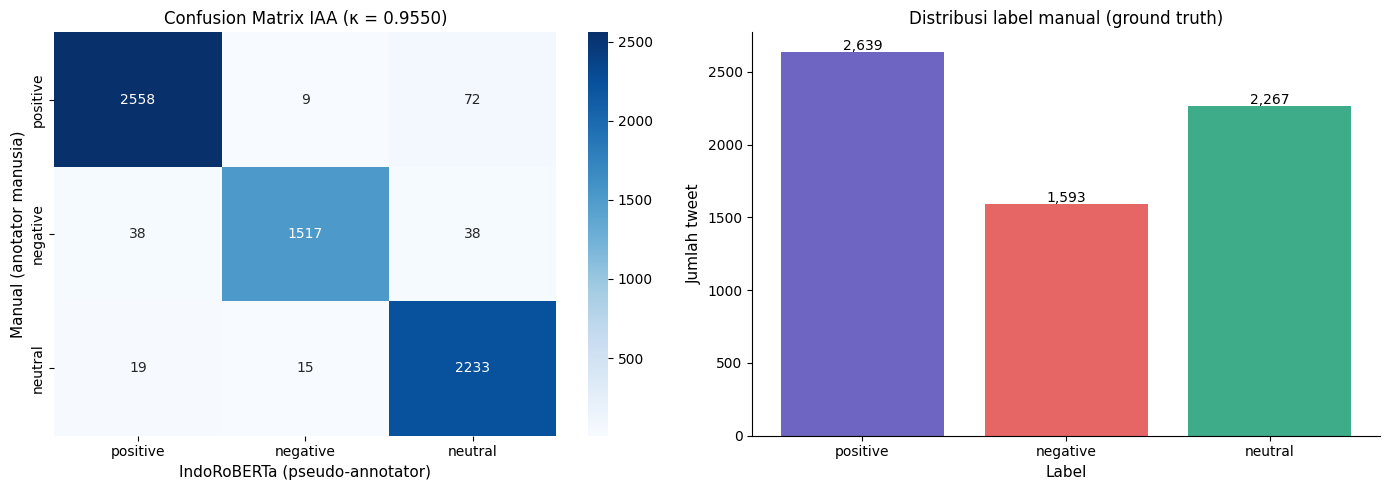


Classification report (manual vs IndoRoBERTa):
              precision    recall  f1-score   support

    positive       0.98      0.95      0.97      1593
    negative       0.95      0.99      0.97      2267
     neutral       0.98      0.97      0.97      2639

    accuracy                           0.97      6499
   macro avg       0.97      0.97      0.97      6499
weighted avg       0.97      0.97      0.97      6499

✔ Grafik IAA disimpan ke: /content/drive/My Drive/skripsi/dataset/mbg/processed/iaa_result.png

 Lanjut ke Notebook 03 — Training IndoBERT+CNN
✅ Fungsi compute_iaa() siap.
   Jalankan: kappa = compute_iaa()
   (Setelah kolom "label" diisi secara manual di mbg_labeled.csv)


In [11]:
def compute_iaa(filepath=OUTPUT_PATH):
    """Hitung Cohen's Kappa antara label manual dan IndoRoBERTa.
    Muat ulang dari file untuk memastikan data terbaru digunakan."""
    df_labeled = pd.read_csv(filepath, low_memory=False)

    valid_labels = ['positive', 'negative', 'neutral']
    df_valid = df_labeled[
        df_labeled['label'].isin(valid_labels) &
        df_labeled['label_roberta'].isin(valid_labels)
    ].copy()

    total         = len(df_labeled)
    total_labeled = len(df_labeled[df_labeled['label'].isin(valid_labels)])
    total_valid   = len(df_valid)

    if total_valid == 0:
        print('⚠️  Belum ada label manual. Isi kolom "label" terlebih dahulu.')
        return None

    # Hitung Cohen's Kappa
    kappa = cohen_kappa_score(df_valid['label'], df_valid['label_roberta'])

    # Interpretasi
    if kappa < 0.20:      interp, status = 'Slight',           '⚠️'
    elif kappa < 0.40:    interp, status = 'Fair',             '⚠️'
    elif kappa < 0.60:    interp, status = 'Moderate',         '⚠️'
    elif kappa < 0.80:    interp, status = 'Substantial',      '✅'
    else:                 interp, status = 'Almost Perfect',   '✅'

    print('=' * 55)
    print(' INTER-ANNOTATOR AGREEMENT (IAA)')
    print('=' * 55)
    print(f' Total data           : {total:,}')
    print(f' Sudah dilabeli manual: {total_labeled:,} ({total_labeled/total*100:.1f}%)')
    print(f' Valid untuk IAA      : {total_valid:,}')
    print(f' Cohen\'s Kappa (κ)    : {kappa:.4f}')
    print(f' Interpretasi         : {interp} {status}')
    print(f' Target (κ ≥ 0.61)    : {"TERPENUHI ✅" if kappa >= 0.61 else "BELUM TERPENUHI ⚠️"}')
    print('=' * 55)

    # ── Confusion matrix IAA ──────────────────────────────────────────────────
    label_order = ['positive', 'negative', 'neutral']
    cm = confusion_matrix(
        df_valid['label'], df_valid['label_roberta'], labels=label_order
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Confusion Matrix IAA
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_order, yticklabels=label_order,
                ax=axes[0])
    axes[0].set_xlabel('IndoRoBERTa (pseudo-annotator)', fontsize=11)
    axes[0].set_ylabel('Manual (anotator manusia)', fontsize=11)
    axes[0].set_title(f'Confusion Matrix IAA (κ = {kappa:.4f})', fontsize=12)

    # Plot 2: Distribusi label manual
    label_counts = df_labeled[df_labeled['label'].isin(valid_labels)]\
                   ['label'].value_counts().reindex(label_order, fill_value=0)
    colors = ['#534AB7', '#E24B4A', '#1D9E75']
    bars = axes[1].bar(label_counts.index, label_counts.values,
                       color=colors, edgecolor='none', alpha=0.85)
    for bar, val in zip(bars, label_counts.values):
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 10,
                     f'{val:,}', ha='center', fontsize=10)
    axes[1].set_xlabel('Label', fontsize=11)
    axes[1].set_ylabel('Jumlah tweet', fontsize=11)
    axes[1].set_title('Distribusi label manual (ground truth)', fontsize=12)
    sns.despine(ax=axes[1])

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/iaa_result.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Classification report ─────────────────────────────────────────────────
    print('\nClassification report (manual vs IndoRoBERTa):')
    print(classification_report(
        df_valid['label'], df_valid['label_roberta'],
        target_names=label_order
    ))

    print(f'✔ Grafik IAA disimpan ke: {OUTPUT_DIR}/iaa_result.png')

    if kappa >= 0.61:
        print('\n Lanjut ke Notebook 03 — Training IndoBERT+CNN')
    else:
        print('\n Tinjau ulang annotation guideline dan perbaiki label yang meragukan.')

    return kappa


# ── Panggil setelah anotasi manual selesai ────────────────────────────────────
kappa = compute_iaa()
print('✅ Fungsi compute_iaa() siap.')
print('   Jalankan: kappa = compute_iaa()')
print('   (Setelah kolom "label" diisi secara manual di mbg_labeled.csv)')

---

## Catatan Metodologis untuk Laporan

### Preprocessing Pipeline

Pipeline preprocessing dirancang dalam **satu jalur tunggal** (Step 1–4) yang menghasilkan `text_bert` sebagai output untuk seluruh model dalam penelitian ini (IndoRoBERTa, IndoBERT+CNN, IndoBERT-only, dan ML baseline melalui TF-IDF).

Keputusan untuk tidak menerapkan stemming dan stopword removal didasarkan pada karakteristik arsitektur IndoBERT:
- **Subword tokenization (WordPiece)**: IndoBERT memecah kata menjadi subword berdasarkan statistik korpus pelatihan. Stemming mengubah surface form kata sehingga token hasil stemming mungkin tidak dikenali (OOV).
- **Attention mechanism**: Mekanisme self-attention pada Transformer memanfaatkan seluruh konteks kalimat, termasuk stopword yang membawa informasi sintaksis. Contoh kritis: menghapus kata negasi *"tidak"* dapat secara langsung membalik sentimen kalimat.
- **Pre-training objective**: IndoBERT dilatih pada teks natural bahasa Indonesia — preprocessing agresif menciptakan distribusi shift antara data pelatihan model dan data inferensi.

### Pelabelan dengan IndoRoBERTa sebagai Pseudo-Annotator

Pendekatan *machine-assisted annotation* digunakan untuk mengatasi keterbatasan jumlah anotator manusia. IndoRoBERTa berperan sebagai anotator ke-2 untuk perhitungan Inter-Annotator Agreement (IAA) menggunakan Cohen's Kappa (κ).

**Ground truth penelitian** menggunakan **label manual peneliti** sebagai referensi utama, bukan label IndoRoBERTa. Nilai κ digunakan semata-mata sebagai validasi konsistensi anotasi, bukan sebagai indikator kualitas model IndoRoBERTa.

### Kolom Label dalam Penelitian

| Kolom | Sumber | Fungsi |
|---|---|---|
| `label` | Anotasi manual peneliti | **Ground truth** — digunakan di seluruh pipeline training |
| `label_roberta` | Prediksi IndoRoBERTa | Hanya untuk perhitungan IAA |
| `confidence_roberta` | Confidence score model | Panduan prioritas review anotasi |

### Limitasi

IndoRoBERTa tidak dilatih secara spesifik pada domain MBG atau teks informal Twitter, sehingga akurasinya pada kasus domain-specific dan sarkasme mungkin terbatas. Hal ini diakui sebagai limitasi dari pendekatan pseudo-IAA yang digunakan.